[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mbanuelos/grad_math_modeling/blob/main/Lectures/Module0_TimeSeries/01_TimeSeriesFoundations.ipynb#copy=true)

# Time Series Foundations: Visualization and Decomposition

## Learning objectives

By the end of this lesson, you should be able to:

- Explain why temporal ordering changes how data should be analyzed.
- Identify trend, seasonality, and changing variance in a time plot.
- Interpret a multiplicative seasonal decomposition.

## Before We Begin

> Prompt: Reflect on a day, week, semester that you remember clearly. What did you do? How were you feeling throughout?

> Visualize the time you chose by drawing it and provide a caption for your visualization. You will have 5 minutes for this prompt.


**Student Learning Outcome (SLO 1):**
> *Diagnose temporal dependence and stationarity by creating and analyzing time series plots,
> rolling statistics, and autocorrelation functions, and justify your conclusions in writing.*

---

### What is a time series?

A **time series** is a sequence of data points collected at successive points in time (i.e., daily
temperatures, monthly sales, or yearly airline passenger counts).

Time series data is fundamentally different from regular tabular data because **the order of
observations matters**. A value today may depend on the value yesterday. This is called
**temporal dependence**.

***
## Part 0 — Imports & Setup

Run the cell below to import everything you need. You do **not** need to modify this cell.

In [1]:
# Standard data & plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# statsmodels: classical time series tools
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Notebook display settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

All imports successful!


***
## Part 1: Load & Visualize the Data

We will use the classic **Air Passengers** dataset: monthly totals of international airline
passengers from 1949–1960.

### 1.1 Load the data

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date','Passengers']

print('Shape:', df.shape)
df.head(10)

Shape: (144, 2)


,Date,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


> 💡 **Syntax reminder:** `df.head(n)` shows the first `n` rows. `parse_dates` tells pandas to
> parse the 'Month' column as a datetime. `index_col` makes that column the row index.
> A DatetimeIndex is essential for time series work in pandas.

### 1.2 Plot the raw time series

**Your turn!** Fill in the blanks to create a line plot of passenger counts over time.

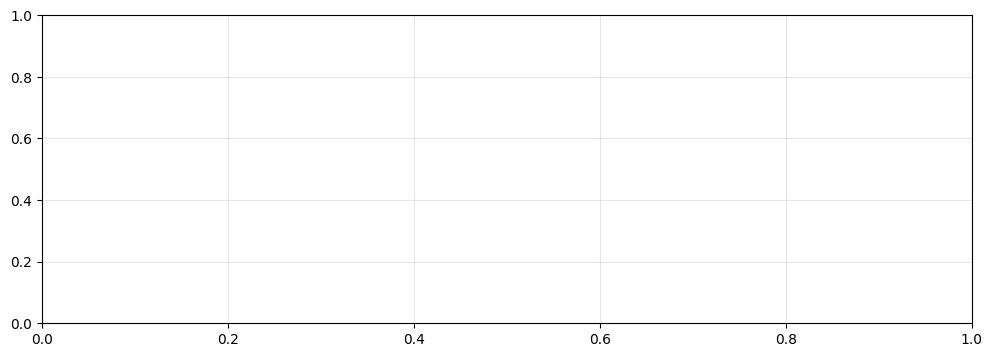

In [ ]:
fig, ax = plt.subplots()

# FILL IN:
ax.plot(???['???'],???['???'], color='steelblue', linewidth=1.5)

ax.set_title('Monthly International Airline Passengers (1949-1960)')
ax.set_xlabel('Date')

# FILL IN: write a descriptive y-axis label
ax.set_ylabel('???')

plt.tight_layout()
plt.show()

### ✏️ Written Response 1.2

Look at your plot and answer the following in 2–4 sentences:

1. Do you notice an overall **trend** (long-term increase or decrease)?
2. Do you notice **seasonality** (a repeating pattern within each year)?
3. Does the **variance** (height of the seasonal swings) stay constant, or does it grow?

*Double-click this cell to edit it.*

> **YOUR ANSWER:**

***
## Part 2: Decomposition

We can formally split a time series into three components:
- **Trend**: the long-run direction
- **Seasonality**: regular, repeating fluctuations (e.g., every 12 months)
- **Residual**: what remains after removing trend and seasonality (ideally random noise)

Because the seasonal swings grow larger as the trend rises, we use a **multiplicative** model:

$$\text{Observed} = \text{Trend} \times \text{Seasonal} \times \text{Residual}$$

### 2.1 Run the decomposition

This cell is complete — run it and study the four panels.

In [ ]:
# period=12 because we have monthly data with annual seasonality
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Multiplicative Decomposition — Air Passengers', y=1.01)
plt.tight_layout()
plt.show()

### ✏️ Written Response 2.1

Answer each question in 2–3 sentences:

1. What does the **trend** component tell you about air travel during this period?
2. What does the **seasonal** component suggest about *when* people tend to fly?
3. Does the **residual** look like random noise, or is there still structure in it?
4. What happens if:
   * the model is `additive`?
   * the `period` changes from `12` to a different value?


> **YOUR ANSWER:**